In [1]:
import sys
sys.path.append("/home/landelle/pytorch-cifar/models")

import random
import numpy as np
import torch
import torchvision
import matplotlib.pyplot as plt

import utils
import exp_models

In [2]:
# Reproducibility

SEED = 2019
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.enabled = False 
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

In [3]:
#transform = torchvision.transforms.transforms.Compose([
#    torchvision.transforms.transforms.ToTensor()
#])
#trainset = torchvision.datasets.CIFAR10(root='/data/landelle/datasets', train=True, download=True, transform=transform)
#testset = torchvision.datasets.CIFAR10(root='/data/landelle/datasets', train=False, download=True, transform=transform)
#trainset, testset

transform = torchvision.transforms.transforms.Compose([
    torchvision.transforms.transforms.ToTensor()
])

trainset = torchvision.datasets.CIFAR100(root='datasets', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR100(root='datasets', train=False, download=True, transform=transform)


Files already downloaded and verified
Files already downloaded and verified


In [4]:
BATCH_SIZE = 100
N_BATCHES_IN_TRAIN_SET = len(trainset) // BATCH_SIZE
N_BATCHES_IN_TEST_SET = len(testset) // BATCH_SIZE
NUM_WORKERS = 8

trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)


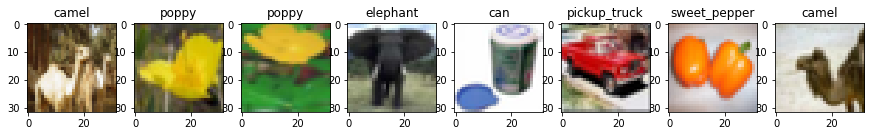

In [5]:
fig, axes = plt.subplots(1, 8, figsize=(15, 2))
for images, labels in trainloader:
    for i in range(8):
        utils.show_np_arr(images[i], ax=axes[i])
        axes[i].set_title(trainset.classes[labels[i]])
    break
    

## No test loss

In [6]:

USE_CUDA = True
N_EPOCHS = 100
N_BATCHES = None
LR = 0.1

model_getter = lambda: exp_models.resnet18(n=100)

def perform_experiment(lambdas):
    print("saving results in", RESULTS_FNAME)
    print_ = utils.get_print(True, fname=RESULTS_FNAME)
    test_accs = {}
    train_losses = {str(k):[] for k in lambdas}
    
    for lambda_ in lambdas:
        print_("Trying lambda=", lambda_)        

        device = torch.device('cuda' if USE_CUDA else 'cpu')
        model = model_getter().to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=LR)
        criterion = torch.nn.CrossEntropyLoss()

        lam_rs = lambda_.reshape((-1, 1, 1, 1, 1))
        lam_rs_tensor = torch.from_numpy(lam_rs).float().to(device)
        NMIX = lam_rs_tensor.shape[0]
        
        # Train mode
        model.train()
        for epoch in range(1, N_EPOCHS + 1):
            print_("Epoch[{}/{}]".format(epoch, N_EPOCHS))
            for batch_id, (images, labels) in enumerate(trainloader):
                if N_BATCHES and batch_id > N_BATCHES:
                    break
                labels, images = labels.to(device), images.to(device)
                images_mx, ys, perms = utils.mixup_data_nmix(NMIX, images, labels, lam_rs_tensor)
                outputs = model(images_mx)
                loss = utils.mixup_criterion_nmix(criterion, outputs, ys, lam_rs_tensor)
                

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                
                #train_losses[str(lambda_)].append(loss_value)
                if batch_id % 50 == 0:
                    print_('train loss:{:.4f} Epoch[{}/{}] Batch[{}/{}]'.format(
                        loss.item(), epoch, N_EPOCHS, batch_id, N_BATCHES_IN_TRAIN_SET))
                    pass



In [7]:
LAMBDAS = [np.array([lam, 1-lam]) for lam in np.linspace(1., .5, 5)]
print(LAMBDAS)

RESULTS_FNAME = "r_cf100_rn18_n2"
with open("results/"+RESULTS_FNAME, "w"):pass
perform_experiment(LAMBDAS)

[array([1., 0.]), array([0.875, 0.125]), array([0.75, 0.25]), array([0.625, 0.375]), array([0.5, 0.5])]
saving results in r_cf100_rn18_n2
Trying lambda= [1. 0.]
Epoch[1/100]
train loss:4.7094 Epoch[1/100] Batch[0/500]
train loss:4.6532 Epoch[1/100] Batch[50/500]


Traceback (most recent call last):
  File "/data/landelle/anaconda3/lib/python3.7/multiprocessing/queues.py", line 242, in _feed
    send_bytes(obj)
  File "/data/landelle/anaconda3/lib/python3.7/multiprocessing/connection.py", line 200, in send_bytes
    self._send_bytes(m[offset:offset + size])
  File "/data/landelle/anaconda3/lib/python3.7/multiprocessing/connection.py", line 404, in _send_bytes
    self._send(header + buf)
  File "/data/landelle/anaconda3/lib/python3.7/multiprocessing/connection.py", line 368, in _send
    n = write(self._handle, buf)
Traceback (most recent call last):
  File "/data/landelle/anaconda3/lib/python3.7/multiprocessing/queues.py", line 242, in _feed
    send_bytes(obj)
  File "/data/landelle/anaconda3/lib/python3.7/multiprocessing/connection.py", line 200, in send_bytes
    self._send_bytes(m[offset:offset + size])
  File "/data/landelle/anaconda3/lib/python3.7/multiprocessing/connection.py", line 404, in _send_bytes
    self._send(header + buf)
  File 

KeyboardInterrupt: 